# NHANES 2021-2023 - Análisis Pre-ML

## Descripción del Dataset
NHANES (National Health and Nutrition Examination Survey) es una encuesta continua del CDC (Centers for Disease Control) que evalúa la salud y nutrición de adultos y niños en Estados Unidos mediante entrevistas, exámenes físicos y pruebas de laboratorio.

**Dataset utilizado:** DEMO_L.xpt (Demographic Variables and Sample Weights)

**Variables principales:**
- `SEQN`: ID único del participante
- `RIAGENDR`: Género (1=Masculino, 2=Femenino)
- `RIDAGEYR`: Edad en años
- `RIDRETH3`: Raza/Etnia
- `DMDEDUC2`: Nivel educativo
- `DMDMARTL`: Estado civil
- `INDFMPIR`: Índice de pobreza familiar (ratio ingreso/umbral de pobreza)

## Objetivo de Machine Learning
**Regresión**: Predecir el nivel socioeconómico de un participante (`INDFMPIR`)

**Target**: `INDFMPIR` (Family Poverty Income Ratio)
- Valores < 1.0 = por debajo del umbral de pobreza
- Valores = 1.0-2.0 = cerca del umbral
- Valores > 2.0 = por encima del umbral de pobreza

**Features potenciales**:
- Demográficas: edad, género, raza/etnia
- Sociales: educación, estado civil, tamaño del hogar
- Geográficas: país de nacimiento

## PASO 1: Cargar Dataset

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Cargar archivo .xpt (formato SAS)
df = pd.read_sas('DEMO_J.xpt', format='xport', encoding='utf-8')

print("✅ Dataset cargado correctamente")

✅ Dataset cargado correctamente


## PASO 2: Ver Estructura del Dataset

In [20]:
df.head()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVSTRA,SDMVPSU,INDFMPIR
0,130378.0,12.0,2.0,1.0,43.0,NaN,5.0,6.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,50055.450807,54374.463898,173.0,2.0,5.00
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,29087.450605,34084.721548,173.0,2.0,5.00
2,130380.0,12.0,2.0,2.0,44.0,NaN,2.0,2.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,80062.674301,81196.277992,174.0,1.0,1.41
3,130381.0,12.0,2.0,2.0,5.0,NaN,5.0,7.0,1.0,71.0,...,2.0,2.0,2.0,3.0,NaN,38807.268902,55698.607106,182.0,2.0,1.53
4,130382.0,12.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,34.0,...,2.0,2.0,3.0,1.0,2.0,30607.519774,36434.146346,182.0,2.0,3.60


In [21]:
df.shape

(11933, 27)

In [22]:
df.dtypes.to_frame(name='dtype')

,dtype
SEQN,float64
SDDSRVYR,float64
RIDSTATR,float64
RIAGENDR,float64
RIDAGEYR,float64
RIDAGEMN,float64
RIDRETH1,float64
RIDRETH3,float64
RIDEXMON,float64
RIDEXAGM,float64


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      11933 non-null  float64
 1   SDDSRVYR  11933 non-null  float64
 2   RIDSTATR  11933 non-null  float64
 3   RIAGENDR  11933 non-null  float64
 4   RIDAGEYR  11933 non-null  float64
 5   RIDAGEMN  377 non-null    float64
 6   RIDRETH1  11933 non-null  float64
 7   RIDRETH3  11933 non-null  float64
 8   RIDEXMON  8860 non-null   float64
 9   RIDEXAGM  2787 non-null   float64
 10  DMQMILIZ  8301 non-null   float64
 11  DMDBORN4  11914 non-null  float64
 12  DMDYRUSR  1875 non-null   float64
 13  DMDEDUC2  7794 non-null   float64
 14  DMDMARTZ  7792 non-null   float64
 15  RIDEXPRG  1503 non-null   float64
 16  DMDHHSIZ  11933 non-null  float64
 17  DMDHRGND  4115 non-null   float64
 18  DMDHRAGZ  4124 non-null   float64
 19  DMDHREDZ  3746 non-null   float64
 20  DMDHRMAZ  4020 non-null   float64
 21  

## PASO 3: Valores Faltantes

In [24]:
# Contar valores faltantes
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("=== VALORES FALTANTES ===")
if len(missing_df) > 0:
    print(missing_df.head(15))
else:
    print("✅ No hay valores faltantes")

=== VALORES FALTANTES ===
          Missing_Count  Missing_Percentage
RIDAGEMN          11556           96.840694
RIDEXPRG          10430           87.404676
DMDYRUSR          10058           84.287271
DMDHSEDZ           9806           82.175480
RIDEXAGM           9146           76.644599
DMDHREDZ           8187           68.608062
DMDHRMAZ           7913           66.311908
DMDHRGND           7818           65.515797
DMDHRAGZ           7809           65.440375
DMDMARTZ           4141           34.702087
DMDEDUC2           4139           34.685326
DMQMILIZ           3632           30.436604
RIDEXMON           3073           25.752116
INDFMPIR           2041           17.103830
DMDBORN4             19            0.159222


## PASO 4: Gráfico del Target

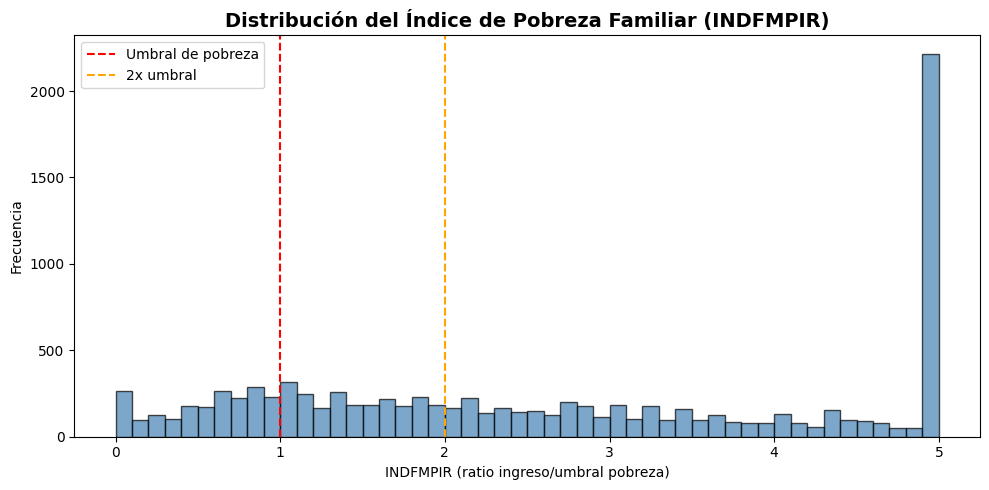


=== ESTADÍSTICAS DEL TARGET ===
count    9.892000e+03
mean     2.708174e+00
std      1.670119e+00
min      5.397605e-79
25%      1.180000e+00
50%      2.500000e+00
75%      4.500000e+00
max      5.000000e+00
Name: INDFMPIR, dtype: float64

Casos por debajo del umbral de pobreza (<1.0): 1938 (19.6%)
Casos en el umbral (1.0-2.0): 2169 (21.9%)
Casos por encima (>=2.0): 5785 (58.5%)


In [25]:
# Distribución del target (eliminar NaN para visualización)
target_clean = df['INDFMPIR'].dropna()

plt.figure(figsize=(10, 5))
plt.hist(target_clean, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribución del Índice de Pobreza Familiar (INDFMPIR)', fontsize=14, fontweight='bold')
plt.xlabel('INDFMPIR (ratio ingreso/umbral pobreza)')
plt.ylabel('Frecuencia')
plt.axvline(x=1.0, color='red', linestyle='--', label='Umbral de pobreza')
plt.axvline(x=2.0, color='orange', linestyle='--', label='2x umbral')
plt.legend()
plt.tight_layout()
plt.show()

# Estadísticas del target
print("\n=== ESTADÍSTICAS DEL TARGET ===")
print(target_clean.describe())
print(f"\nCasos por debajo del umbral de pobreza (<1.0): {(target_clean < 1.0).sum()} ({(target_clean < 1.0).sum()/len(target_clean)*100:.1f}%)")
print(f"Casos en el umbral (1.0-2.0): {((target_clean >= 1.0) & (target_clean < 2.0)).sum()} ({((target_clean >= 1.0) & (target_clean < 2.0)).sum()/len(target_clean)*100:.1f}%)")
print(f"Casos por encima (>=2.0): {(target_clean >= 2.0).sum()} ({(target_clean >= 2.0).sum()/len(target_clean)*100:.1f}%)")

---
# LIMPIEZA DE DATOS

## Seleccionar Variables Relevantes

In [26]:
# Seleccionar columnas relevantes para el análisis
columns_to_keep = [
    'INDFMPIR',      # TARGET: Índice de pobreza familiar
    'RIAGENDR',      # Género
    'RIDAGEYR',      # Edad en años
    'RIDRETH3',      # Raza/Etnia
    'DMDEDUC2',      # Nivel educativo (adultos)
    'DMDMARTL',      # Estado civil
    'DMDHHSIZ',      # Tamaño del hogar
    'DMDFMSIZ',      # Tamaño de la familia
    'DMDBORN4',      # País de nacimiento
    'DMDCITZN'       # Ciudadanía
]

# Filtrar solo columnas que existen en el dataset
columns_available = [col for col in columns_to_keep if col in df.columns]
df_clean = df[columns_available].copy()

print(f"Columnas seleccionadas: {len(columns_available)}")
print(f"Shape inicial: {df_clean.shape}")

Columnas seleccionadas: 7
Shape inicial: (11933, 7)


## Tratamiento de Valores Faltantes

In [27]:
# Eliminar filas donde el target está ausente (no se puede predecir sin target)
print(f"Filas antes de eliminar target NaN: {len(df_clean)}")
df_clean = df_clean.dropna(subset=['INDFMPIR'])
print(f"Filas después de eliminar target NaN: {len(df_clean)}")

# Para el resto de variables: imputar con mediana (numéricas) o moda (categóricas)
for col in df_clean.columns:
    if col == 'INDFMPIR':  # Ya limpiamos el target
        continue
    
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['float64', 'int64']:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Verificar
remaining_nulls = df_clean.isnull().sum().sum()
print(f"\nValores faltantes después de limpieza: {remaining_nulls}")

if remaining_nulls == 0:
    print("✅ Todos los valores faltantes fueron tratados")
else:
    print(f"⚠️ Quedan {remaining_nulls} valores faltantes")

Filas antes de eliminar target NaN: 11933
Filas después de eliminar target NaN: 9892

Valores faltantes después de limpieza: 0
✅ Todos los valores faltantes fueron tratados


## Tratamiento de Outliers

In [28]:
# Estadísticas de variables numéricas
print("=== ESTADÍSTICAS NUMÉRICAS ===")
print(df_clean.describe())

# En NHANES, los valores extremos de INDFMPIR están truncados a 5.0
print(f"\nValores de INDFMPIR = 5.0 (truncados): {(df_clean['INDFMPIR'] == 5.0).sum()}")
print("Nota: CDC trunca INDFMPIR en 5.0 para proteger privacidad de personas con ingresos muy altos")

print(f"\n✅ No se requiere tratamiento de outliers (los valores extremos son por diseño del dataset)")

=== ESTADÍSTICAS NUMÉRICAS ===
           INDFMPIR     RIAGENDR      RIDAGEYR     RIDRETH3     DMDEDUC2  \
count  9.892000e+03  9892.000000  9.892000e+03  9892.000000  9892.000000   
mean   2.708174e+00     1.531440  3.833937e+01     3.324201     3.901638   
std    1.670119e+00     0.499036  2.544978e+01     1.504258     0.918546   
min    5.397605e-79     1.000000  5.397605e-79     1.000000     1.000000   
25%    1.180000e+00     1.000000  1.400000e+01     3.000000     4.000000   
50%    2.500000e+00     2.000000  3.750000e+01     3.000000     4.000000   
75%    4.500000e+00     2.000000  6.200000e+01     4.000000     4.000000   
max    5.000000e+00     2.000000  8.000000e+01     7.000000     9.000000   

          DMDHHSIZ     DMDBORN4  
count  9892.000000  9892.000000  
mean      3.207845     1.145774  
std       1.695465     0.352898  
min       1.000000     1.000000  
25%       2.000000     1.000000  
50%       3.000000     1.000000  
75%       4.000000     1.000000  
max       7.

---
# PREPROCESAMIENTO

## Encoding de Variables Categóricas

In [29]:
df_encoded = df_clean.copy()

# Todas las variables son numéricas codificadas (NHANES usa códigos numéricos)
# No necesitamos one-hot encoding, pero verificamos tipos de datos

print("=== TIPOS DE DATOS ===")
print(df_encoded.dtypes)

# Asegurar que todas las columnas sean numéricas
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        # Convertir a numérico si es posible
        df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce')

print(f"\n✅ Variables ya están codificadas numéricamente")
print(f"Shape: {df_encoded.shape}")

=== TIPOS DE DATOS ===
INDFMPIR    float64
RIAGENDR    float64
RIDAGEYR    float64
RIDRETH3    float64
DMDEDUC2    float64
DMDHHSIZ    float64
DMDBORN4    float64
dtype: object

✅ Variables ya están codificadas numéricamente
Shape: (9892, 7)


## Separar Features y Target

In [30]:
# Target
y = df_encoded['INDFMPIR'].values

# Features (todas excepto el target)
X = df_encoded.drop('INDFMPIR', axis=1).values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nNombre de features:")
print(df_encoded.drop('INDFMPIR', axis=1).columns.tolist())

X shape: (9892, 6)
y shape: (9892,)

Nombre de features:
['RIAGENDR', 'RIDAGEYR', 'RIDRETH3', 'DMDEDUC2', 'DMDHHSIZ', 'DMDBORN4']


## Train-Test Split Manual (80-20)

In [31]:
# Configuración
np.random.seed(42)
test_size = 0.2

# Generar índices aleatorios
n_samples = len(X)
indices = np.random.permutation(n_samples)

# Calcular punto de corte
test_size_abs = int(n_samples * test_size)
train_size_abs = n_samples - test_size_abs

# Dividir índices
train_indices = indices[:train_size_abs]
test_indices = indices[train_size_abs:]

# Crear conjuntos
X_train = X[train_indices]
X_test = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]

print(f"✅ Split completado")
print(f"Train: {X_train.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")
print(f"\nINDFMPIR promedio en Train: {y_train.mean():.2f}")
print(f"INDFMPIR promedio en Test: {y_test.mean():.2f}")

✅ Split completado
Train: 7914 muestras
Test: 1978 muestras

INDFMPIR promedio en Train: 2.72
INDFMPIR promedio en Test: 2.67


## Escalado Manual (StandardScaler)

Fórmula: `x_scaled = (x - mean) / std`

**IMPORTANTE**: Calcular media y desviación estándar SOLO con datos de entrenamiento para evitar data leakage.

In [32]:
# Calcular media y desviación estándar del TRAIN set
mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)

# Evitar división por cero (columnas constantes)
std_train[std_train == 0] = 1

# Aplicar escalado
X_train_scaled = (X_train - mean_train) / std_train
X_test_scaled = (X_test - mean_train) / std_train  # Usar estadísticas del train

# Convertir a float explícitamente (prevenir errores de tipo)
X_train_scaled = X_train_scaled.astype(float)
X_test_scaled = X_test_scaled.astype(float)

print("✅ Escalado completado")
print(f"\nMedia de X_train_scaled (primeras 5 features): {X_train_scaled.mean(axis=0)[:5]}")
print(f"Desv. Std de X_train_scaled (primeras 5 features): {X_train_scaled.std(axis=0)[:5]}")

✅ Escalado completado

Media de X_train_scaled (primeras 5 features): [ 2.37924975e-16 -3.69232626e-17 -5.87258038e-16 -2.11186472e-16
 -6.12207895e-17]
Desv. Std de X_train_scaled (primeras 5 features): [1. 1. 1. 1. 1.]


---
# VALIDACIÓN FINAL

## 1. Verificar Data Leakage

In [33]:
# Verificar que no hay índices compartidos entre train y test
shared_indices = np.intersect1d(train_indices, test_indices)

if len(shared_indices) == 0:
    print("✅ No hay data leakage (índices únicos en train y test)")
else:
    print(f"⚠️ ALERTA: {len(shared_indices)} índices compartidos detectados")

✅ No hay data leakage (índices únicos en train y test)


## 2. Verificar NaN e Infinitos

In [34]:
# Verificar NaN
nan_train = np.isnan(X_train_scaled).sum()
nan_test = np.isnan(X_test_scaled).sum()

# Verificar infinitos
inf_train = np.isinf(X_train_scaled).sum()
inf_test = np.isinf(X_test_scaled).sum()

print(f"NaN en X_train_scaled: {nan_train}")
print(f"NaN en X_test_scaled: {nan_test}")
print(f"Infinitos en X_train_scaled: {inf_train}")
print(f"Infinitos en X_test_scaled: {inf_test}")

if nan_train == 0 and nan_test == 0 and inf_train == 0 and inf_test == 0:
    print("\n✅ Datos limpios (sin NaN ni infinitos)")
else:
    print("\n⚠️ ALERTA: Hay NaN o infinitos en los datos")

NaN en X_train_scaled: 0
NaN en X_test_scaled: 0
Infinitos en X_train_scaled: 0
Infinitos en X_test_scaled: 0

✅ Datos limpios (sin NaN ni infinitos)


## 3. Comparar Distribuciones Train vs Test

In [35]:
# Comparar media y std de todas las features
print("=== COMPARACIÓN TRAIN vs TEST (todas las features) ===")
print("\nMEDIA:")
print(f"Train: {X_train_scaled.mean(axis=0)}")
print(f"Test:  {X_test_scaled.mean(axis=0)}")

print("\nDESVIACIÓN ESTÁNDAR:")
print(f"Train: {X_train_scaled.std(axis=0)}")
print(f"Test:  {X_test_scaled.std(axis=0)}")

print("\n✅ Las distribuciones deberían ser similares (train estandarizado, test escalado con stats de train)")

=== COMPARACIÓN TRAIN vs TEST (todas las features) ===

MEDIA:
Train: [ 2.37924975e-16 -3.69232626e-17 -5.87258038e-16 -2.11186472e-16
 -6.12207895e-17  1.60304757e-16]
Test:  [ 0.06050551  0.00975138  0.05056548 -0.03413864  0.00480678  0.05003148]

DESVIACIÓN ESTÁNDAR:
Train: [1. 1. 1. 1. 1. 1.]
Test:  [0.99508002 0.99956823 1.02518166 1.01775844 1.00502646 1.04879039]

✅ Las distribuciones deberían ser similares (train estandarizado, test escalado con stats de train)


## Resumen Final

In [36]:
print("="*60)
print("RESUMEN DEL PREPROCESAMIENTO")
print("="*60)
print(f"Dataset original: {df.shape}")
print(f"Dataset después de limpieza: {df_clean.shape}")
print(f"Features seleccionadas: {X.shape[1]}")
print(f"Train set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"\nTarget (INDFMPIR - Índice de Pobreza Familiar):")
print(f"  - Mínimo: {y.min():.2f}")
print(f"  - Promedio: {y.mean():.2f}")
print(f"  - Máximo: {y.max():.2f}")
print(f"  - Por debajo del umbral de pobreza (<1.0): {(y < 1.0).sum()} casos")
print(f"\n✅ Datos listos para entrenamiento de modelos de regresión")
print("="*60)

RESUMEN DEL PREPROCESAMIENTO
Dataset original: (11933, 27)
Dataset después de limpieza: (9892, 7)
Features seleccionadas: 6
Train set: (7914, 6)
Test set: (1978, 6)

Target (INDFMPIR - Índice de Pobreza Familiar):
  - Mínimo: 0.00
  - Promedio: 2.71
  - Máximo: 5.00
  - Por debajo del umbral de pobreza (<1.0): 1938 casos

✅ Datos listos para entrenamiento de modelos de regresión
